In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sbi.analysis import pairplot
import yaml
import scipy

# Import local packages
from examples.unif_norm import (
    prior_pdf,
    get_approximate_posterior_density,
    true_posterior_pdf,
    approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_diff_against_x,
    plot_leakage_factors
)
from sbc.sbc_tools import plot_sbc_all
results_path_npe_c = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm/npe_c/"
results_path_tsnpe = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm/tsnpe/"
algorithm_names = ["npe_c", "tsnpe", "nle_mcmc", "nle_vi", "nre"]
algorithm_KLs_squared_norms_ID = {"npe_c": 0,
                                  "tsnpe": 0,
                                  "nle_mcmc": 0,
                                  "nle_vi": 0,
                                  "nre": 0} # The ID of the experiment in each algorithm directory

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
squared_norms_dicts = {}
KLs_squared_norms_configs = {}

for algorithm_name in algorithm_names:
    KLs_squared_norms_ID = algorithm_KLs_squared_norms_ID[algorithm_name]

    results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm" + f"/{algorithm_name}/"
    config_path = results_path + f"/KLs_squared_norms{KLs_squared_norms_ID}.yaml"
    squared_norms_path = results_path + f"/KLs_squared_norms{KLs_squared_norms_ID}_squared_norms_dict.npz"

    # Load config
    with open(config_path, "r") as f:
        KLs_squared_norms_config = yaml.safe_load(f)
    KLs_squared_norms_configs[algorithm_name] = KLs_squared_norms_config

    # Load squared norms
    squared_norms_dict_ = dict(np.load(squared_norms_path))
    squared_norms_dicts[algorithm_name] = squared_norms_dict_



In [3]:
def plot_training_parameter_squared_norms(squared_norms_dict, d, exclude_rounds=None, alpha=0.1):
    if exclude_rounds is None:
        exclude_rounds = []

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_xlabel("Round")
    ax.set_ylabel(r"Average $||\theta||^2$ from round's proposal")

    mean_means = []
    mean_lqs = []
    mean_uqs = []

    se_means = []
    se_lqs = []
    se_uqs = []

    rs = []

    r = 0
    while f"round_{r}" in squared_norms_dict:
        if r not in exclude_rounds:
            squared_norms = squared_norms_dict[f"round_{r}"]
            # shape: (num_repetitions, num_simulations_per_round)

            # Per-repetition statistics
            means = np.mean(squared_norms, axis=1)
            lqs = np.quantile(squared_norms, alpha / 2, axis=1)
            uqs = np.quantile(squared_norms, 1 - alpha / 2, axis=1)

            R = len(means)

            # Averages across repetitions
            mean_means.append(np.mean(means))
            mean_lqs.append(np.mean(lqs))
            mean_uqs.append(np.mean(uqs))

            # Standard errors across repetitions
            se_means.append(np.std(means, ddof=1) / np.sqrt(R))
            se_lqs.append(np.std(lqs, ddof=1) / np.sqrt(R))
            se_uqs.append(np.std(uqs, ddof=1) / np.sqrt(R))

            rs.append(r)

        r += 1

    mean_means = np.array(mean_means)
    mean_lqs = np.array(mean_lqs)
    mean_uqs = np.array(mean_uqs)

    se_means = np.array(se_means)
    se_lqs = np.array(se_lqs)
    se_uqs = np.array(se_uqs)

    # True values
    true_lq = scipy.stats.chi2.ppf(alpha / 2, df=d)
    true_uq = scipy.stats.chi2.ppf(1 - alpha / 2, df=d)

    # Plot mean with ±1 SE
    ax.errorbar(
        rs,
        mean_means,
        yerr=se_means,
        fmt="o",
        capsize=4,
        markersize=4,
        label="Approximate mean ± 1 SE",
    )

    # Plot lower quantile with ±1 SE
    ax.errorbar(
        rs,
        mean_lqs,
        yerr=se_lqs,
        fmt="o",
        capsize=4,
        markersize=4,
        label=f"Approximate {100*alpha/2:.1f}% quantile ± 1 SE",
    )

    # Plot upper quantile with ±1 SE
    ax.errorbar(
        rs,
        mean_uqs,
        yerr=se_uqs,
        fmt="o",
        capsize=4,
        markersize=4,
        label=f"Approximate {100*(1-alpha/2):.1f}% quantile ± 1 SE",
    )

    ax.axhline(d, color="k", linestyle="--", label="True mean")
    ax.fill_between(rs, true_lq, true_uq, alpha=0.2, color="gray",
                    label=f"True {100*alpha/2:.1f}% and {100*(1-alpha/2):.1f}% quantile region.")

    ax.set_title(
        f"Mean and quantiles of $||\\theta||^2$ per round (±1 SE)"
    )

    ax.vlines(
        rs,
        mean_lqs,
        mean_uqs,
        colors="gray",
        linewidth=1,
        alpha=0.7,
        zorder=0,
    )

    ax.set_xticks(rs)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [4]:
# MOVE TO SRC CODE WHEN HAPPY
def plot_training_parameter_squared_norms_hist(squared_norms_dict, d, exclude_rounds=None, alpha=0.1, bins=None, histtype="step"):
    # ONLY WORKS WITH ONE REPETITION
    if squared_norms_dict["round_0"].ndim > 1:
        # If we have multiple samples, we only consider the first one
        for k, v in squared_norms_dict.items():
            squared_norms_dict[k] = v[0,:]
    print(squared_norms_dict.keys())

    # List of rounds to exclude from plot
    if exclude_rounds is None:
        exclude_rounds = []
    fig, ax = plt.subplots(figsize=(10,5))
    ax.set_xlabel(r"$||\theta||^2$")
    r = 0
    while f"round_{r}" in squared_norms_dict:
        if not r in exclude_rounds:
            color = plt.gca()._get_lines.get_next_color()
            squared_norms = squared_norms_dict[f"round_{r}"]
            if bins is not None:
                if histtype == "bar":
                    ax.hist(squared_norms, alpha=alpha, density=True, label=f"Round {r}", bins=bins, color=color, histtype=histtype)
                elif histtype == "step":
                    ax.hist(squared_norms, density=True, bins=bins, color=color, label=f"Round {r}", histtype=histtype)
            else:
                if histtype == "bar":
                    ax.hist(squared_norms, alpha=alpha, density=True, label=f"Round {r}", color=color, histtype=histtype)
                elif histtype == "step":
                    ax.hist(squared_norms, density=True, color=color, label=f"Round {r}", histtype=histtype)
        r += 1
    xl, xu = ax.get_xlim()
    x_range = np.linspace(xl, xu, 1000)
    ax.plot(x_range, scipy.stats.chi2.pdf(x_range, df=d), color="k", label=r"pdf of $\chi^2_d$")
    ax.legend()

In [5]:
algorithm_name = "nle_vi"
squared_norms_dict = squared_norms_dicts[algorithm_name]
d = KLs_squared_norms_configs[algorithm_name]["d"]

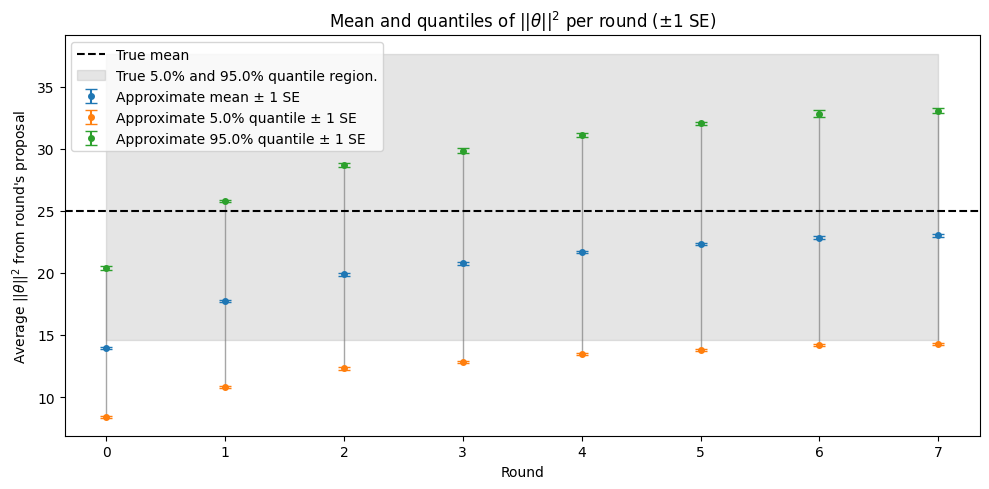

In [6]:
plot_training_parameter_squared_norms(squared_norms_dict, d=d, exclude_rounds=[])

dict_keys(['round_0', 'round_1', 'round_2', 'round_3', 'round_4', 'round_5', 'round_6', 'round_7'])


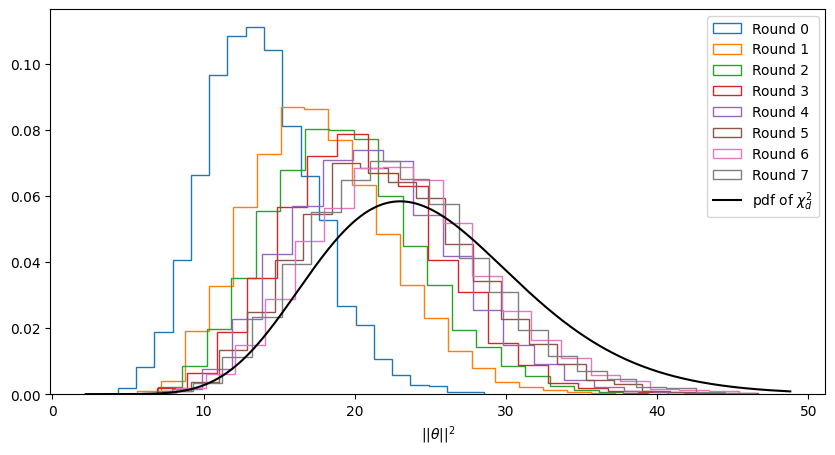

In [7]:
plot_training_parameter_squared_norms_hist(squared_norms_dict, d, alpha=0.7,
                                           exclude_rounds=[], bins=20, histtype="step")